# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dalam proyek ini menggunakan Pima Indians Diabetes Database untuk menguji sistem MLOps(automated prepprocessing, MLflow tracking, CI/CD, dan monitoring).

**Sumber data**: Repositori Publik Kaggle ("uciml/pima-indians-diabetes-database") oleh National Institute of Diabetes and Digestive and Kidney Diseases.

**Format&Target** : Format & Target: File berbentuk .csv dengan variabel target Outcome (0 = Tidak Diabetes, 1 = Diabetes).

Fitur Prediktor (Numerik):
1. Pregnancies (Jumlah kehamilan)
2. Glucose (Kadar glukosa)
3. BloodPressure (Tekanan darah)
4. SkinThickness (Ketebalan kulit)
5. Insulin (Kadar insulin)
6. BMI (Indeks massa tubuh)
7. DiabetesPedigreeFunction (Riwayat genetika keluarga)
8. Age (Usia)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
!pip install pandas numpy scikit-learn mlflow dagshub matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Download versi terbaru dataset dari Kaggle menggunakan kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Path tempat menyimpan file dataset:", path)

# 2. Mencari file CSV di dalam folder hasil download
files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]
print("File yang ditemukan:", csv_files)

# 3. Memuat dataset ke dalam Pandas DataFrame
# Menggunakan file pertama yang ditemukan (diabetes.csv)
if csv_files:
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)
    print("\nDataset berhasil dimuat ke dalam DataFrame!")
    print(f"Ukuran Dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")
else:
    print("\nFile CSV tidak ditemukan di folder tersebut.")

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path tempat menyimpan file dataset: /kaggle/input/pima-indians-diabetes-database
File yang ditemukan: ['diabetes.csv']

Dataset berhasil dimuat ke dalam DataFrame!
Ukuran Dataset: 768 baris dan 9 kolom


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
!rm -rf namadataset_raw

In [ ]:
import pandas as pd

# The dataset has already been loaded into the 'df' DataFrame in a previous cell.
# We will directly use the 'df' DataFrame for displaying its head and info.

# Menampilkan 5 data teratas
print("Struktur Data:")
print(df.head())
print("\nInformasi Dataset:")
print(df.info())

Struktur Data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- STATISTIK DESKRIPTIF DATASET ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



--- PENGECEKAN DATA KOSONG & DUPLIKAT ---
Jumlah Missing Values per Kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Jumlah Data Duplikat dalam Dataset: 0

--- VISUALISASI DISTRIBUSI TARGET ---


/tmp/ipykernel_4813/2109448249.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='viridis')


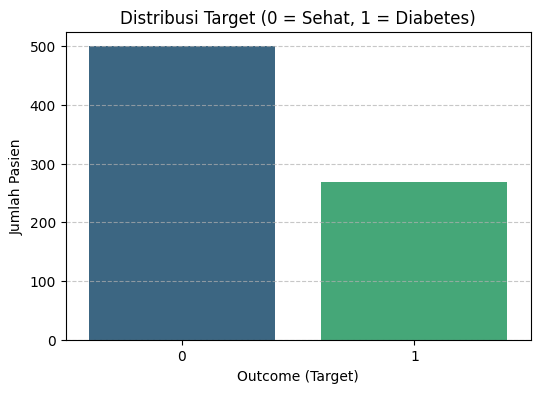


--- VISUALISASI MATRIKS KORELASI ---


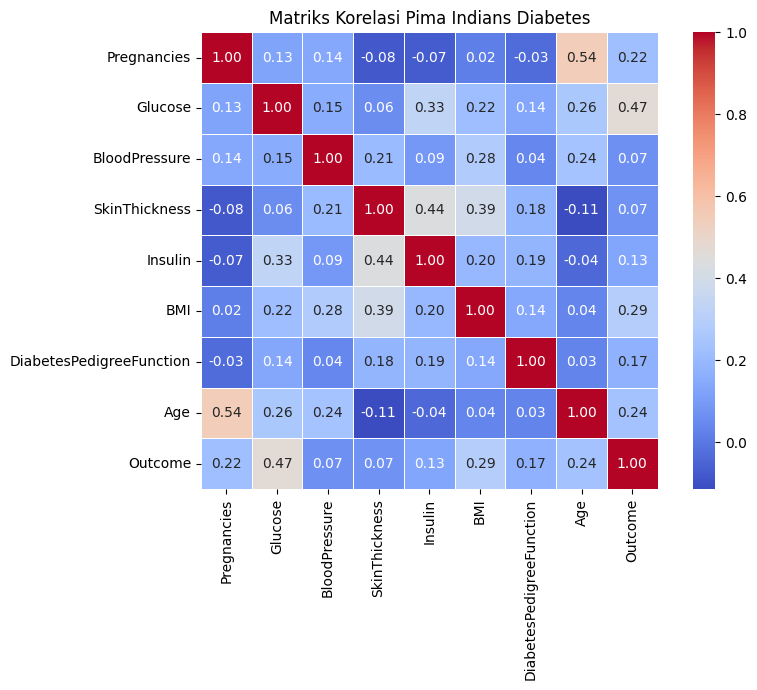

In [ ]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menampilkan Statistik Deskriptif
print("--- STATISTIK DESKRIPTIF DATASET ---")
display(df.describe())

# 2. Memeriksa Missing Values dan Data Duplikat
print("\n--- PENGECEKAN DATA KOSONG & DUPLIKAT ---")
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum())
print(f"\nJumlah Data Duplikat dalam Dataset: {df.duplicated().sum()}")

# 3. Visualisasi Distribusi Kelas Target (Outcome)
print("\n--- VISUALISASI DISTRIBUSI TARGET ---")
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', palette='viridis')
plt.title('Distribusi Target (0 = Sehat, 1 = Diabetes)')
plt.xlabel('Outcome (Target)')
plt.ylabel('Jumlah Pasien')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Visualisasi Matriks Korelasi Antar Fitur
print("\n--- VISUALISASI MATRIKS KORELASI ---")
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriks Korelasi Pima Indians Diabetes')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [24]:
# 5. Data Preprocessing

# A. Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# B. Menangani Missing Values (Mengisi nilai 0 yang tidak masuk akal dengan Median)
# Pada dataset diabetes, nilai 0 pada Glucose, BloodPressure, SkinThickness, Insulin, dan BMI adalah missing value tersembunyi
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_with_zero:
    X[col] = X[col].replace(0, np.nan)
    X[col] = X[col].fillna(X[col].median())

# C. Split Dataset menjadi Train (80%) dan Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# D. Standarisasi Fitur (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# E. Mengembalikan ke bentuk DataFrame untuk siap disimpan
train_preprocessed = pd.DataFrame(X_train_scaled, columns=X.columns)
train_preprocessed['Outcome'] = y_train.values

test_preprocessed = pd.DataFrame(X_test_scaled, columns=X.columns)
test_preprocessed['Outcome'] = y_test.values

# F. Membuat folder penyimpanan hasil preprocessing
output_dir = 'preprocessing/namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Menyimpan hasil akhir ke file CSV sesuai kriteria
train_preprocessed.to_csv(f'{output_dir}/train_preprocessed.csv', index=False)
test_preprocessed.to_csv(f'{output_dir}/test_preprocessed.csv', index=False)

print("=== Preprocessing Selesai ===")
print(f"File berhasil disimpan di folder: {output_dir}")
print(f"Ukuran Data Train: {train_preprocessed.shape}")
print(f"Ukuran Data Test: {test_preprocessed.shape}")

=== Preprocessing Selesai ===
File berhasil disimpan di folder: preprocessing/namadataset_preprocessing
Ukuran Data Train: (614, 9)
Ukuran Data Test: (154, 9)


In [ ]:
import os

# Create the directory if it doesn't exist
output_dir = 'preprocessing/namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Save the preprocessed data to CSV files
pd.DataFrame(X_train_scaled, columns=X_train.columns).to_csv(os.path.join(output_dir, 'train_preprocessed.csv'), index=False)
pd.DataFrame(X_test_scaled, columns=X_test.columns).to_csv(os.path.join(output_dir, 'test_preprocessed.csv'), index=False)
y_train.to_csv(os.path.join(output_dir, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(output_dir, 'y_test.csv'), index=False)

print(f"Preprocessed data saved to '{output_dir}'")

Preprocessed data saved to 'preprocessing/namadataset_preprocessing'


In [ ]:
%%writefile modelling_tuning.py
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import mlflow
import mlflow.sklearn
import dagshub

# 1. Inisialisasi DagsHub (Sudah langsung aktif pakai nama akunmu!)
dagshub.init(repo_owner="reginasitumorang826", repo_name="Membangun_model", mlflow=True)

# 2. Memuat Data Hasil Preprocessing
X_train = pd.read_csv('preprocessing/namadataset_preprocessing/train_preprocessed.csv')
X_test = pd.read_csv('preprocessing/namadataset_preprocessing/test_preprocessed.csv')
y_train = pd.read_csv('preprocessing/namadataset_preprocessing/y_train.csv').squeeze()
y_test = pd.read_csv('preprocessing/namadataset_preprocessing/y_test.csv').squeeze()

# 3. Menetapkan Nama Eksperimen MLflow
mlflow.set_experiment("Diabetes_Tuning_Model")

with mlflow.start_run():
    # 4. Hyperparameter Tuning dengan Grid Search
    rf = RandomForestClassifier(random_state=42)
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [5, 10]
    }

    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # 5. Menghitung Metrik Evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # 6. MANUAL LOGGING PARAMETER & METRIK
    mlflow.log_param("best_n_estimators", grid_search.best_params_['n_estimators'])
    mlflow.log_param("best_max_depth", grid_search.best_params_['max_depth'])

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)

    # 7. LOGGING 2 ARTEFAK TAMBAHAN (Syarat Advance)
    os.makedirs('plots', exist_ok=True)

    # Artefak Tambahan 1: Confusion Matrix Plot
    plt.figure(figsize=(6,5))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.title('Confusion Matrix - Tuned Model')
    plt.savefig('plots/confusion_matrix.png')
    plt.close()
    mlflow.log_artifact('plots/confusion_matrix.png', 'visualizations')

    # Artefak Tambahan 2: Feature Importance Plot
    plt.figure(figsize=(8,5))
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    sns.barplot(x=importances[indices], y=X_train.columns[indices], palette='viridis')
    plt.title('Feature Importances')
    plt.tight_layout()
    plt.savefig('plots/feature_importance.png')
    plt.close()
    mlflow.log_artifact('plots/feature_importance.png', 'visualizations')

    # Log Model Akhir
    mlflow.sklearn.log_model(best_model, "tuned_rf_model")

    print(f"Tuning Model Berhasil Dilatih! Best Accuracy: {acc:.4f}")

Writing modelling_tuning.py


In [ ]:
!python modelling_tuning.py

                      ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                      


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=57d86e28-0c1c-489b-85e4-4abb03a5b7b2&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=27755ef8bfb9a4f0b897a0184fdff5d333c4d3c9dab0404f658c9218551c68b2


⠸ Waiting for authorization
Traceback (most recent call last):
  File "/content/modelling_tuning.py", line 14, in <module>
    dagshub.init(repo_owner="reginasitumorang826", repo_name="Membangun_model", mlflow=True)
  File "/usr/local/lib/python3.12/dist-packages/dagshub/common/init.py", line 86, in init
    repo_api = RepoAPI(f"{repo_owner}/{repo_name}", host=host)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/dagshub/common/api/repo.py", line 78, in __init__
    self.auth = dagshub.auth.get_authenticator(host=host)
                ^^^^^^

In [ ]:
!python modelling.py

                      ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                      


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=2d5d35cd-043b-497d-a468-4d4960eecb79&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=3044a347afee68a4cf181fe49d9a9e735e0f718a06728bc172242e5a4f0559b1


⠸ Waiting for authorization
Accessing as reginasitumorang826
Initialized MLflow to track repo "reginasitumorang826/Membangun_model"
Repository reginasitumorang826/Membangun_model initialized!
2026/05/26 15:07:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 15:07:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' 

In [ ]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
mlflow
dagshub
matplotlib
seaborn

Writing requirements.txt


In [ ]:
%%writefile Dagshub.txt
https://dagshub.com/reginasitumorang826/Membangun_model

Writing Dagshub.txt


In [22]:
%%writefile automate.Regina.py
# -*- coding: utf-8 -*-
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def pipeline_preprocessing(input_path, output_dir):
    # 1. Load data
    print("Memuat dataset dari:", input_path)
    df = pd.read_csv(input_path)

    # 2. Preprocessing / Pembersihan Data Singkat
    # Memisahkan fitur (X) dan target (y) - Asumsi kolom terakhir adalah target 'Outcome'
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # Mengatasi missing value dasar (jika ada) dengan nilai mean
    X = X.fillna(X.mean())

    # Split data menjadi Train (80%) dan Test (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scaling fitur menggunakan StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Mengembalikan ke bentuk DataFrame untuk disimpan ke CSV
    train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
    train_df['Outcome'] = y_train.values

    test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
    test_df['Outcome'] = y_test.values

    # 3. Menyimpan hasil preprocessing ke folder tujuan
    os.makedirs(output_dir, exist_ok=True)

    train_path = os.path.join(output_dir, 'train_preprocessed.csv')
    test_path = os.path.join(output_dir, 'test_preprocessed.csv')

    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print("Sukses! File train dan test preprocessed telah disimpan di:", output_dir)

if __name__ == '__main__':
    # Menjalankan fungsi otomatisasi preprocessing
    pipeline_preprocessing(
        input_path='namadataset_raw/diabetes.csv',
        output_dir='preprocessing/namadataset_preprocessing'
    )


Writing automate.Regina.py


In [26]:
!pip install wget

import os
import wget

# 1. Membuat folder namadataset_raw yang bersih dan benar (tanpa typo)
os.makedirs('/content/namadataset_raw', exist_ok=True)

# 2. Mengunduh ulang file diabetes.csv langsung ke dalam folder tersebut
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
output_path = '/content/namadataset_raw/diabetes.csv'

print("Sedang mengunduh ulang file mentah...")
wget.download(url, out=output_path)
print("\n\nSelesai! Folder 'namadataset_raw' dan file 'diabetes.csv' sudah muncul kembali.")

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=f49d9110fa8f468833a4ecbcc7de6da4ca25e0b2479fd182af42786979208ef0
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
Sedang mengunduh ulang file mentah...


Selesai! Folder 'namadataset_raw' dan file 'diabetes.csv' sudah muncul kembali.
